In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC
from IPython.display import display

### Déclaration des données

In [152]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
arbres = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", 
                      "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", 
                      "bois_mort_houppier", "plaie_houppier", "esperance_maintien", "classification_diagnostic"]]

prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", 
            "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", 
            "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [93]:
np.unique(arbres['classe_age'])

array(['A', 'AM', 'J', 'JA'], dtype=object)

### Encodage manuel

In [156]:
arbres_ordinales = {
    'classe_age' : ['J', 'JA', 'A', 'AM'],
    'classe_hauteur' : ['H1', 'H2', 'H3', 'H4', 'H5'],
    'classe_circonference' : ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7'],
    'vigueur_pousse' : ['D', 'P', 'MP', 'PP'],
    'plaie_collet' : ['AU', 'RCPPL', 'RCPLS', 'RCPLC', 'RCPLCF', 'RCPLNC', 'RCPLNS'],
    'fissure_tronc' : ['TFF', 'TFO', 'TPF'],
    'plaie_tronc' : ['ZZ', 'TPPL', 'TPLS', 'TPLC', 'TPLCF', 'TPLNC'],
    'fissure_houppier' : ['HFF ', 'HFO ', 'HPF '],
    'bois_mort_houppier' : ['HBMI ', 'HBMU ', 'HPBM '],
    'plaie_houppier' : ['ZZ', 'HPPL', 'HPLS', 'HPLC', 'HPLNC']
}

# Boucle pour appliquer l'ordinal encoding selon l'ordre défini
for col, order in arbres_ordinales.items():
    if col in arbres.columns:
        mapping = {cat: i for i, cat in enumerate(order)}
        arbres[col] = arbres[col].map(mapping)

In [158]:
for col in arbres.columns:
    print(col)
    print(np.unique(arbres[col]))

type_sol
['CS' 'G' 'GR' 'Gr' 'MA' 'P' 'S' 'TV']
classe_age
[0 1 2 3]
classe_hauteur
[0 1 2 3 4]
classe_circonference
[0 1 2 3 4 5 6]
port_arbre
['A' 'L' 'R5' 'SL']
vigueur_pousse
[0 1 2 3]
plaie_collet
[0 1 2 3 4 5 6]
fissure_tronc
[0 1 2]
plaie_tronc
[0 1 2 3 4 5]
fissure_houppier
[0 1 2]
bois_mort_houppier
[0 1 2]
plaie_houppier
[0 1 2 3 4]
esperance_maintien
[1. 2. 3. 4.]
classification_diagnostic
['C1' 'C2' 'C3' 'C4' 'C5']


In [786]:
for col in prev.columns:
    # Récupérer la liste des valeurs autorisées dans prev pour la colonne col
    valeurs_autorisees = set(arbres_trie[col].unique())
    # Supprimer dans arbres_trie les lignes dont la valeur n'est pas dans valeurs_autorisees
    prev = prev[prev[col].isin(valeurs_autorisees)]

KeyError: 'type_sol'

In [22]:
def preprocess_arbres(prev):
    
    prev_just_categories = {
        'type_sol' : ['CS', 'G', 'GR', 'Gr', 'MA', 'P', 'S'],
        'port_arbre' : ['A', 'L', 'R5', 'SL']
    }

    prev_ordre_categories = {
        'classe_age' : ['J', 'JA', 'A'],
        'classe_hauteur' : ['H1', 'H2', 'H3', 'H4'],
        'classe_circonference' : ['C1', 'C2', 'C3', 'C4'],
        'vigueur_pousse' : ['P', 'MP', 'PP'],
        'plaie_collet' : ['RCPPL', 'RCPLS', 'RCPLC', 'RCPLNC'],
        'fissure_tronc' : ['TPF', 'TFF'],
        'plaie_tronc' : ['TPPL', 'TPLS', 'TPLC', 'TPLNC'],
        'fissure_houppier' : ['HPF ', 'HFF '],
        'bois_mort_houppier' : ['HPBM ', 'HBMI '],
        'plaie_houppier' : ['HPPL', 'HPLS', 'HPLNC']
    }

    # Encodage ordinal pour les colonnes avec ordre défini
    for col, classes in prev_ordre_categories.items():
        ordinal = OrdinalEncoder(categories=[classes])
        prev[col] = ordinal.fit_transform(prev[[col]])

    # Encodage OneHot pour les colonnes qui restent des catégories simples
    for col, classes in prev_just_categories.items():
        onehot = OneHotEncoder(categories=[classes], sparse_output=False)
        transformed = onehot.fit_transform(prev[[col]])
        colonnes = [f"ohe_{cat}" for cat in classes]
        temp_df = pd.DataFrame(transformed, columns=colonnes, index=prev.index)
        prev = prev.drop(columns=[col], axis=1)
        prev_trie = pd.concat([temp_df, prev], axis=1)
    
    return prev_trie

In [ ]:
for c in prev_trie.columns:
    if c not in all_columns:
        prev_trie = prev_trie.drop(columns = [c], axis=1)

In [24]:
prev_final = preprocess_arbres(prev)

In [769]:
arbres_trie.columns

Index(['ohe_A', 'ohe_L', 'ohe_R5', 'ohe_SL', 'ohe_CS', 'ohe_G', 'ohe_GR',
       'ohe_Gr', 'ohe_MA', 'ohe_P', 'ohe_S', 'classe_age', 'classe_hauteur',
       'classe_circonference', 'vigueur_pousse', 'plaie_collet',
       'fissure_tronc', 'plaie_tronc', 'fissure_houppier',
       'bois_mort_houppier', 'plaie_houppier', 'esperance_maintien'],
      dtype='object')

In [26]:
prev_final.columns

Index(['ohe_A', 'ohe_L', 'ohe_R5', 'ohe_SL', 'classe_age', 'classe_hauteur',
       'classe_circonference', 'vigueur_pousse', 'plaie_collet',
       'fissure_tronc', 'plaie_tronc', 'fissure_houppier',
       'bois_mort_houppier', 'plaie_houppier', 'esperance_maintien'],
      dtype='object')

In [30]:
arbres.head(3)

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien,classification_diagnostic
ID_ARBRE,,,,,,,,,,,,,,


### Divisions en X_train, X_test, Y_train, Y_test

In [326]:
X_train, X_test, Y_train, Y_test = train_test_split(arbres_trie, y, test_size=0.20)

In [328]:
print("X_train :")
display(X_train.head(2))
print("X_test :")
display(X_test.head(2))

X_train :


,ohe_A,ohe_L,ohe_R5,ohe_SL,ohe_CS,ohe_G,ohe_GR,ohe_Gr,ohe_MA,ohe_P,...,classe_hauteur,classe_circonference,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,,,,,,,,,
95,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
120,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0


X_test :


,ohe_A,ohe_L,ohe_R5,ohe_SL,ohe_CS,ohe_G,ohe_GR,ohe_Gr,ohe_MA,ohe_P,...,classe_hauteur,classe_circonference,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,,,,,,,,,
521,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
498,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0


### Entrainement modèle

In [331]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold

In [374]:
model = KNC(n_neighbors = 3, metric='manhattan')

In [376]:
model.fit(X_train, Y_train["classification_diagnostic"])

KNeighborsClassifier(metric='manhattan', n_neighbors=3)

In [378]:
model.score(X_test, Y_test)

0.8557692307692307

In [380]:
previsions_sklearn = model.predict(X_test)
previsions_sklearn

array(['C2', 'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1',
       'C1', 'C1', 'C2', 'C3', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C3', 'C2', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1',
       'C1', 'C1', 'C1', 'C2', 'C1'], dtype=object)

In [81]:
cv = KFold(10)

In [84]:
cross_validation_train = [cross_val_score(KNC(k, metric='minkowski', p=2), arbres_hot, y["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

In [65]:
cross_validation_test = [cross_val_score(KNC(k, metric='minkowski', p=2), X_train, Y_train["classification_diagnostic"], cv=cv).mean() for k in range(1, 21)]

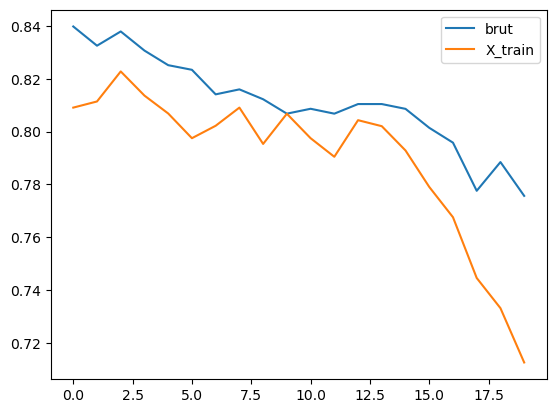

In [76]:
plt.plot(cross_validation_train, label="brut")
plt.plot(cross_validation_test, label="X_train")
plt.legend()

### GridSearchCV

In [343]:
from sklearn.model_selection import GridSearchCV

In [345]:
grid = {
    'metric' : ['euclidean', 'manhattan'],
    'n_neighbors' : [2, 3, 4, 5, 6, 7, 9],
}

In [349]:
GridSearch = GridSearchCV(KNC(), grid, cv = KFold(8))
best_score = 0;
best_part = 0;
scores = []

for part in np.arange(0.1, 0.5, 0.1):
    X_train2, X_test2, Y_train2, Y_test2 = train_test_split(arbres_trie, y, test_size=part) 
    GridSearch.fit(X_train2, Y_train2["classification_diagnostic"])
    best_knn = GridSearch.best_estimator_
    score = best_knn.score(X_test, Y_test)
    scores.append(score)
    if best_score < score:
        best_score = score
        best_part = part

In [351]:
best_part

0.2

In [353]:
GridSearch.fit(X_train, Y_train["classification_diagnostic"])

GridSearchCV(cv=KFold(n_splits=8, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [2, 3, 4, 5, 6, 7, 9]})

In [372]:
best_knn = GridSearch.best_estimator_
print(best_knn)
print(best_knn.score(X_test, Y_test))

KNeighborsClassifier(metric='manhattan', n_neighbors=3)
0.8557692307692307


In [368]:
grid_pred = best_knn.predict(X_test)
grid_pred

array(['C2', 'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1',
       'C1', 'C1', 'C2', 'C3', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C3', 'C2', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1',
       'C1', 'C1', 'C1', 'C2', 'C1'], dtype=object)

### Submition

In [283]:
sub = pd.DataFrame({'classification_diagnostic': grid_pred})
sub.index.name = "ID_ARBRE"
id_arbre = prev_trie.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [285]:
sub.to_csv("sub_gridsearch3.csv")

In [262]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C4
